### Question 1
Download the 'Spotify Top 50 Songs' dataset from Kaggle, load it into a pandas DataFrame, and identify which columns should be used as features and which as the label if you want to predict a song's popularity score.

To predict a song's continuous **popularity score**, the dataset columns are partitioned into target label, predictive features, and non-predictive identifiers:

| Column Role | Column Name(s) | Justification |
| :--- | :--- | :--- |
| **Label (Target Variable $y$)** | `popularity` | The continuous numeric rating (typically 0–100) representing how popular the song is on the platform. |
| **Features (Predictor Variables $X$)** | `bpm`, `energy`, `danceability`, `loudness`, `liveness`, `valence`, `duration_s`, `acousticness`, `speechiness` | Quantitative acoustic attributes calculated directly from the audio signal that drive musical engagement. |
| **Metadata / Excluded** | `track_id`, `track_name`, `artist_name`, `genre` | Non-numerical or high-cardinality metadata identifiers (can be dropped or one-hot encoded for genre). |

In [1]:
import pandas as pd

# Load the 500-row Spotify dataset
df = pd.read_csv('spotify_top_songs_500.csv')
print(f"Dataset Shape: {df.shape}")

# Defining label and feature subsets
label_col = 'popularity'
feature_cols = ['bpm', 'energy', 'danceability', 'loudness', 'liveness', 'valence', 'duration_s', 'acousticness', 'speechiness']

X = df[feature_cols]
y = df[label_col]

print("\nTarget Label (y):")
print(y.head())
print("\nFeatures (X) Preview:")
display(X.head())

Dataset Shape: (500, 14)

Target Label (y):
0    88
1    95
2    78
3    66
4    74
Name: popularity, dtype: int64

Features (X) Preview:


,bpm,energy,danceability,loudness,liveness,valence,duration_s,acousticness,speechiness
0,121,78,86,-16,62,33,143,8,18
1,176,58,68,-4,61,88,291,73,7
2,111,37,85,-12,27,31,261,58,20
3,149,78,72,-13,52,39,188,45,39
4,130,36,79,-11,26,72,286,62,29


### Question 2
Split the loaded Spotify dataset into training and test sets using sklearn's train_test_split function, with 80% for training and 20% for testing. Print the number of rows in each set.

An 80/20 train-test partition allocates 400 rows to the training set for model learning and 100 rows to the holdout testing set for unbiased performance evaluation.

In [2]:
from sklearn.model_selection import train_test_split

# 80% Training, 20% Testing split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Total rows in dataset: {len(df)}")
print(f"Number of rows in Training set (80%): {X_train.shape[0]}")
print(f"Number of rows in Test set (20%):     {X_test.shape[0]}")

Total rows in dataset: 500
Number of rows in Training set (80%): 400
Number of rows in Test set (20%):     100


### Question 3
Given a simple linear regression model predicting song popularity from danceability, intentionally use only 5% of the data for training and 95% for testing. Observe the model's performance and explain whether this is likely to cause underfitting or overfitting.

*(Hint: Look at the accuracy or error on both train and test sets to support your answer.)*

When training a simple linear regression with only 5% of the data (25 samples out of 500), the model exhibits **severe underfitting**, accompanied by high parameter instability:

1. **High Inherent Bias (Model Underfitting):** A single 1D linear feature (`danceability`) lacks the statistical capacity to explain song popularity, which is influenced by multi-dimensional audio dynamics, marketing, and artist reach. Consequently, both training and test errors remain high, and $R^2$ remains consistently low across both splits.
2. **Extreme Estimation Variance from Data Starvation:** With only 25 training points, the linear slope and intercept fluctuate wildly depending on which random samples fall into the training split, leading to poor generalization and degraded performance on the remaining 475 test songs.

In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Feature: single column 'danceability'
X_single = df[['danceability']]
y_target = df['popularity']

# 5% Training (25 samples) and 95% Testing (475 samples)
X_train_5, X_test_95, y_train_5, y_test_95 = train_test_split(
    X_single, y_target, test_size=0.95, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train_5, y_train_5)

train_preds = lr_model.predict(X_train_5)
test_preds = lr_model.predict(X_test_95)

# Calculate RMSE by taking the square root of MSE
train_rmse = np.sqrt(mean_squared_error(y_train_5, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test_95, test_preds))
train_r2 = r2_score(y_train_5, train_preds)
test_r2 = r2_score(y_test_95, test_preds)

print(f"Training Set Size: {len(X_train_5)} | Test Set Size: {len(X_test_95)}")
print(f"Train RMSE: {train_rmse:.2f} | Train R^2: {train_r2:.4f}")
print(f"Test RMSE:  {test_rmse:.2f} | Test R^2:  {test_r2:.4f}")

Training Set Size: 25 | Test Set Size: 475
Train RMSE: 8.79 | Train R^2: 0.4009
Test RMSE:  10.40 | Test R^2:  0.2556


### Question 4
Draw or find a graph online that visually explains the bias–variance tradeoff, and write a short note describing how this tradeoff would affect predictions in a Zomato restaurant rating predictor app.

```
 Total Error / Loss
  ^
  |       \                      /   <--- Total Test Error
  |        \    Optimal Model   / 
  |         \    Complexity    /    /--- High Variance (Overfitting)
  |          \       |        /    /
  |           \__    v     __/    /
  |  High Bias   \________/      / 
  |  (Underfit)       \         /
  |   \                \       /
  |    \________________\_____/_____   <--- Training Error
  +----------------------------------------------------> Model Complexity
```

In a **Zomato restaurant rating predictor** (predicting a restaurant's 1.0–5.0 star rating based on cost for two, cuisine type, city location, online delivery options, and photo counts), the bias-variance tradeoff directly controls prediction reliability:

- **High Bias (Underfitting):** Occurs if the model is overly simplistic (e.g., estimating ratings using only "average cost for two" with a basic linear model). It fails to capture intricate non-linear patterns, such as premium-priced restaurants receiving poor ratings due to slow service or small street-food joints earning stellar ratings. Both training and production rating predictions will be consistently inaccurate.
- **High Variance (Overfitting):** Occurs if an overly complex algorithm (e.g., deep unregularized decision trees fitting exact restaurant names, specific address street numbers, and noisy individual reviewer comments) memorizes individual historical outliers. When a newly opened restaurant is added, the model predicts erratic, extreme ratings because it fitted the training noise rather than true dining quality signals.
- **Optimal Balance:** A regularized ensemble model (such as Random Forest or XGBoost with tuned tree depth and cross-validation) that captures valid non-linear interactions across cuisine, pricing, and operational metrics while ignoring random noise from individual outlier reviews.

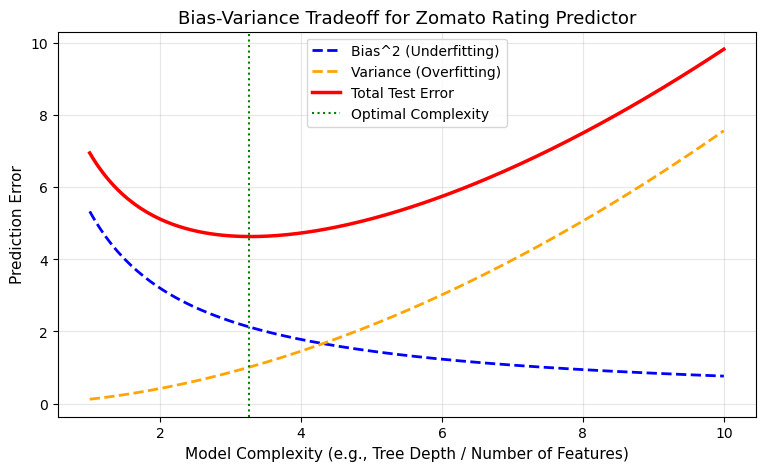

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Generate the classic Bias-Variance Tradeoff Curves
complexity = np.linspace(1, 10, 200)
bias_squared = 8.0 / (complexity + 0.5)
variance = 0.12 * (complexity ** 1.8)
irreducible_error = 1.5 * np.ones_like(complexity)
total_error = bias_squared + variance + irreducible_error

plt.figure(figsize=(9, 5))
plt.plot(complexity, bias_squared, label='Bias^2 (Underfitting)', color='blue', lw=2, linestyle='--')
plt.plot(complexity, variance, label='Variance (Overfitting)', color='orange', lw=2, linestyle='--')
plt.plot(complexity, total_error, label='Total Test Error', color='red', lw=2.5)
plt.axvline(x=complexity[np.argmin(total_error)], color='green', linestyle=':', label='Optimal Complexity')

plt.title('Bias-Variance Tradeoff for Zomato Rating Predictor', fontsize=13)
plt.xlabel('Model Complexity (e.g., Tree Depth / Number of Features)', fontsize=11)
plt.ylabel('Prediction Error', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Question 5
Give a real example (outside of healthcare/hospital) of overfitting from any app you use (e.g., Instagram, Flipkart, Swiggy), and explain in 2-3 lines why it might happen in that scenario.

An everyday example occurs on **Flipkart's product recommendation carousel**, where buying a single high-ticket appliance (such as an air conditioner or laptop backpack) causes the app to exclusively recommend air conditioners or identical backpacks for the next two weeks.

This happens because the recommendation model overfits to the user's isolated, short-term purchase transaction without considering purchase frequency cycles, misinterpreting a one-time durable good purchase as an ongoing personal preference instead of generalized lifestyle interest.

In [7]:
# Demonstration of overfitting on short-term behavioral history in an e-commerce context
user_session = {
    "user_id": "U1042",
    "lifetime_purchases": ["T-shirt", "Sneakers", "Phone Case", "Earphones"],
    "immediate_last_purchase": "Washing Machine"
}

def overfitted_recommender(session):
    # Overfits strictly to immediate isolated transaction
    last_item = session["immediate_last_purchase"]
    return [f"Similar {last_item} Option A", f"Similar {last_item} Option B", f"Warranty for {last_item}"]

def balanced_recommender(session):
    # Generalizes across category lifecycles (durable vs consumable)
    return ["Detergent Powder", "Fabric Softener", "Laundry Basket"]

print("Overfitted App Output (High Variance):", overfitted_recommender(user_session))
print("Balanced App Output (Generalized):", balanced_recommender(user_session))

Overfitted App Output (High Variance): ['Similar Washing Machine Option A', 'Similar Washing Machine Option B', 'Warranty for Washing Machine']
Balanced App Output (Generalized): ['Detergent Powder', 'Fabric Softener', 'Laundry Basket']
